In [1]:
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

print("UNSW-NB15 model training environment ready!")

UNSW-NB15 model training environment ready!


In [2]:
train_path = "../data/UNSW-NB15/ml_ready/UNSW_NB15_training_ml_ready.csv"
test_path = "../data/UNSW-NB15/ml_ready/UNSW_NB15_testing_ml_ready.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Datasets loaded successfully!")
print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

Datasets loaded successfully!
Training shape: (175341, 195)
Testing shape: (82332, 195)


In [3]:
print("Training label distribution:")
print(train_df["Binary_Label"].value_counts())

print("\nTesting label distribution:")
print(test_df["Binary_Label"].value_counts())

print("\nLabel meaning:")
print("0 = NORMAL")
print("1 = ATTACK")

Training label distribution:
Binary_Label
1    119341
0     56000
Name: count, dtype: int64

Testing label distribution:
Binary_Label
1    45332
0    37000
Name: count, dtype: int64

Label meaning:
0 = NORMAL
1 = ATTACK


In [4]:
X_train = train_df.drop(columns=["Binary_Label"])
y_train = train_df["Binary_Label"]

X_test = test_df.drop(columns=["Binary_Label"])
y_test = test_df["Binary_Label"]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (175341, 194)
y_train shape: (175341,)
X_test shape: (82332, 194)
y_test shape: (82332,)


In [5]:
print("Training features:", X_train.shape[1])
print("Testing features:", X_test.shape[1])

print("\nFeatures match:", list(X_train.columns) == list(X_test.columns))

Training features: 194
Testing features: 194

Features match: True


In [6]:
print("Training missing values:", X_train.isnull().sum().sum())
print("Testing missing values:", X_test.isnull().sum().sum())

print("Training infinite values:",
      np.isinf(X_train.select_dtypes(include=[np.number])).sum().sum())

print("Testing infinite values:",
      np.isinf(X_test.select_dtypes(include=[np.number])).sum().sum())

Training missing values: 0
Testing missing values: 0
Training infinite values: 0
Testing infinite values: 0


In [7]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

print("Training Random Forest...")
rf_model.fit(X_train, y_train)

print("Random Forest training completed successfully!")

Training Random Forest...
Random Forest training completed successfully!


In [8]:
y_pred = rf_model.predict(X_test)

y_probability = rf_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred))

Predictions generated successfully!
Number of predictions: 82332


In [9]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_probability)

print("=" * 50)
print("UNSW-NB15 RANDOM FOREST RESULTS")
print("=" * 50)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

UNSW-NB15 RANDOM FOREST RESULTS
Accuracy : 0.8703
Precision: 0.8165
Recall   : 0.9861
F1 Score : 0.8933
ROC-AUC  : 0.9794


In [10]:
print("Classification Report")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["NORMAL", "ATTACK"],
        zero_division=0
    )
)

Classification Report
              precision    recall  f1-score   support

      NORMAL       0.98      0.73      0.83     37000
      ATTACK       0.82      0.99      0.89     45332

    accuracy                           0.87     82332
   macro avg       0.90      0.86      0.86     82332
weighted avg       0.89      0.87      0.87     82332



In [11]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[26953 10047]
 [  632 44700]]


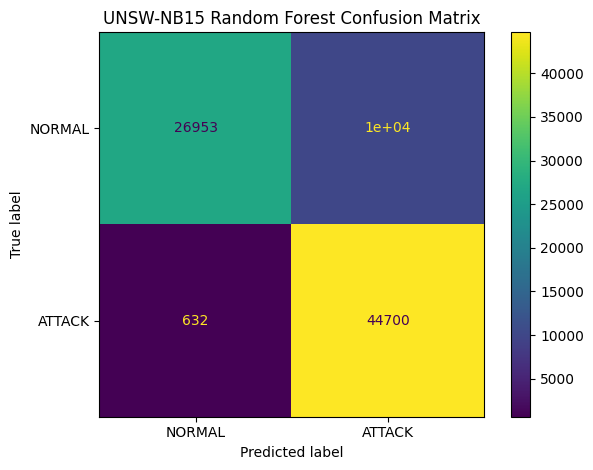

In [12]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["NORMAL", "ATTACK"]
)

disp.plot()

plt.title("UNSW-NB15 Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

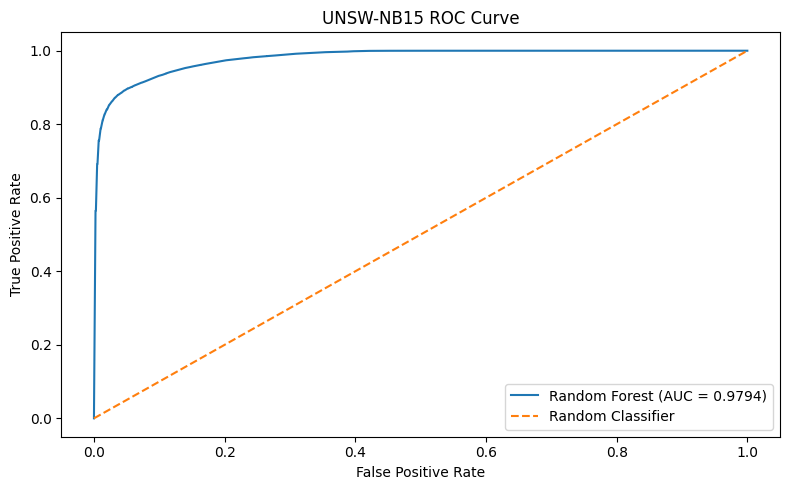

In [13]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(8, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("UNSW-NB15 ROC Curve")
plt.legend()

plt.tight_layout()
plt.show()

In [14]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 20 Important Features:")
print(feature_importance.head(20))

Top 20 Important Features:
            Feature  Importance
6              sttl    0.089975
28     ct_state_ttl    0.064338
5              rate    0.060715
9             dload    0.052212
8             sload    0.047406
3            sbytes    0.039586
37       ct_srv_dst    0.034578
20           tcprtt    0.033181
32   ct_dst_src_ltm    0.033066
27       ct_srv_src    0.032482
7              dttl    0.031787
23            smean    0.031632
2             dpkts    0.031233
188       state_INT    0.030791
0               dur    0.029025
4            dbytes    0.027226
21           synack    0.027185
13           dinpkt    0.025988
12           sinpkt    0.025657
24            dmean    0.023382


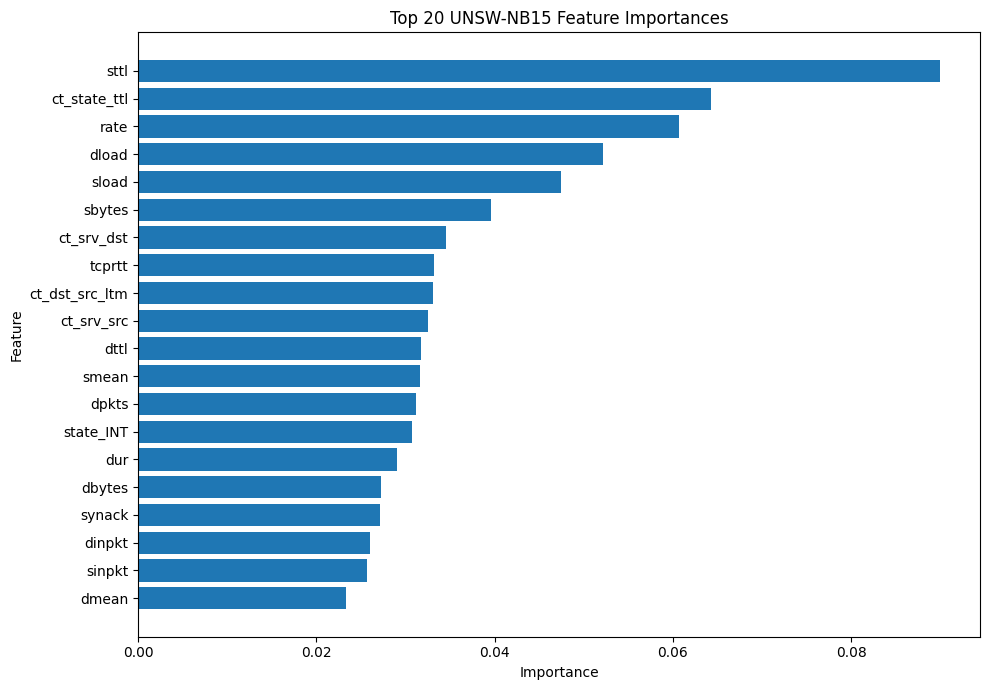

In [15]:
top_features = feature_importance.head(20).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 UNSW-NB15 Feature Importances")

plt.tight_layout()
plt.show()

In [16]:
evaluation_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

print("UNSW-NB15 Evaluation Summary:")
print(evaluation_results)

UNSW-NB15 Evaluation Summary:
      Metric     Score
0   Accuracy  0.870293
1  Precision  0.816483
2     Recall  0.986058
3   F1 Score  0.893294
4    ROC-AUC  0.979427


In [17]:
output_dir = "../data/UNSW-NB15/ml_ready"

os.makedirs(output_dir, exist_ok=True)

evaluation_path = os.path.join(
    output_dir,
    "unsw_nb15_random_forest_evaluation.csv"
)

evaluation_results.to_csv(
    evaluation_path,
    index=False
)

print("Evaluation results saved successfully!")
print("Path:", evaluation_path)

Evaluation results saved successfully!
Path: ../data/UNSW-NB15/ml_ready\unsw_nb15_random_forest_evaluation.csv


In [18]:
feature_importance_path = os.path.join(
    output_dir,
    "unsw_nb15_feature_importance.csv"
)

feature_importance.to_csv(
    feature_importance_path,
    index=False
)

print("Feature importance saved successfully!")
print("Path:", feature_importance_path)

Feature importance saved successfully!
Path: ../data/UNSW-NB15/ml_ready\unsw_nb15_feature_importance.csv


In [19]:
model_dir = "../models"

os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(
    model_dir,
    "unsw_nb15_random_forest.joblib"
)

joblib.dump(
    rf_model,
    model_path
)

print("UNSW-NB15 Random Forest model saved successfully!")
print("Path:", model_path)

UNSW-NB15 Random Forest model saved successfully!
Path: ../models\unsw_nb15_random_forest.joblib


In [20]:
print("=" * 65)
print("FINAL UNSW-NB15 ML SUMMARY")
print("=" * 65)

print(f"Training samples   : {len(X_train):,}")
print(f"Testing samples    : {len(X_test):,}")
print(f"Number of features : {X_train.shape[1]}")
print()
print(f"Accuracy           : {accuracy:.4f}")
print(f"Precision          : {precision:.4f}")
print(f"Recall             : {recall:.4f}")
print(f"F1 Score           : {f1:.4f}")
print(f"ROC-AUC            : {roc_auc:.4f}")
print()
print("Model: Random Forest")
print("Dataset: UNSW-NB15")
print("Task: Binary Network Intrusion Detection")
print("=" * 65)

FINAL UNSW-NB15 ML SUMMARY
Training samples   : 175,341
Testing samples    : 82,332
Number of features : 194

Accuracy           : 0.8703
Precision          : 0.8165
Recall             : 0.9861
F1 Score           : 0.8933
ROC-AUC            : 0.9794

Model: Random Forest
Dataset: UNSW-NB15
Task: Binary Network Intrusion Detection
